In [41]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


In [42]:
# 2. GENERATE AND PREPARE DATA
# make_circles creates a non-linear dataset shaped like two concentric circles.
# The inner circle is one class and the outer ring is the other class.
X, y = make_circles(n_samples=300, noise=0.15, factor=0.5, random_state=42)

# Split into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# SCALING — Crucial for both SVM and KNN.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training features:", X_train_scaled.shape)
print("Testing features :", X_test_scaled.shape)


Training features: (210, 2)
Testing features : (90, 2)


In [43]:
# 3. INITIALIZE ALL THREE MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN (K=7)"          : KNeighborsClassifier(n_neighbors=7),
    "SVM (RBF, C=1)"     : SVC(kernel='rbf', C=1, gamma='scale', probability=True)
}


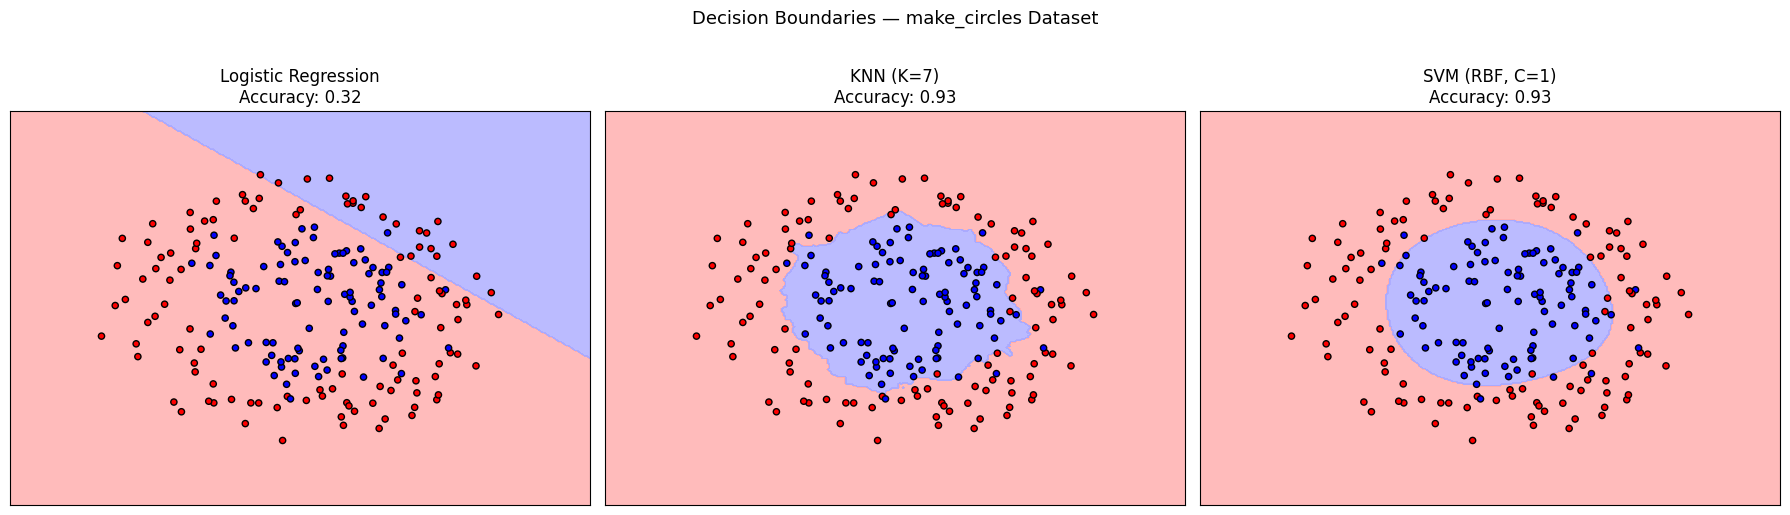

In [44]:
# 4. DECISION BOUNDARY VISUALIZATION
# The make_circles dataset has 2 features, so it can be plotted directly in 2D.
X_train_2d = X_train_scaled
X_test_2d  = X_test_scaled

# Plotting function — same as class example.
def plot_decision_boundary(model, X, y, title, ax):
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold  = ListedColormap(['#FF0000', '#0000FF'])

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

# Train separate models on 2D data for visualization.
models_2d = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN (K=7)"          : KNeighborsClassifier(n_neighbors=7),
    "SVM (RBF, C=1)"     : SVC(kernel='rbf', C=1, gamma='scale')
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models_2d.items()):
    # Train on 2D data.
    model.fit(X_train_2d, y_train)

    # Accuracy on 2D data.
    accuracy = model.score(X_test_2d, y_test)
    full_title = f"{name}\nAccuracy: {accuracy:.2f}"

    # Plot decision boundary.
    plot_decision_boundary(model, X_train_2d, y_train, full_title, ax)

plt.suptitle(
    "Decision Boundaries — make_circles Dataset",
    y=1.02,
    fontsize=13
)
plt.tight_layout()
plt.show()


MODEL: Logistic Regression
Accuracy : 0.3222
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000
ROC-AUC  : 0.4443

              precision    recall  f1-score   support

     Class 0       0.36      0.76      0.49        38
     Class 1       0.00      0.00      0.00        52

    accuracy                           0.32        90
   macro avg       0.18      0.38      0.24        90
weighted avg       0.15      0.32      0.21        90



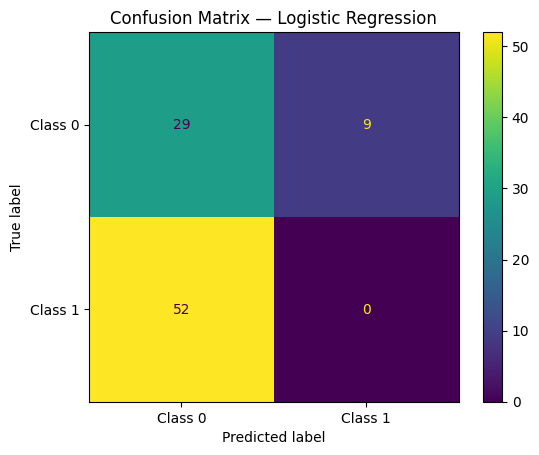

MODEL: KNN (K=7)
Accuracy : 0.9333
Precision: 0.9792
Recall   : 0.9038
F1-Score : 0.9400
ROC-AUC  : 0.9927

              precision    recall  f1-score   support

     Class 0       0.88      0.97      0.93        38
     Class 1       0.98      0.90      0.94        52

    accuracy                           0.93        90
   macro avg       0.93      0.94      0.93        90
weighted avg       0.94      0.93      0.93        90



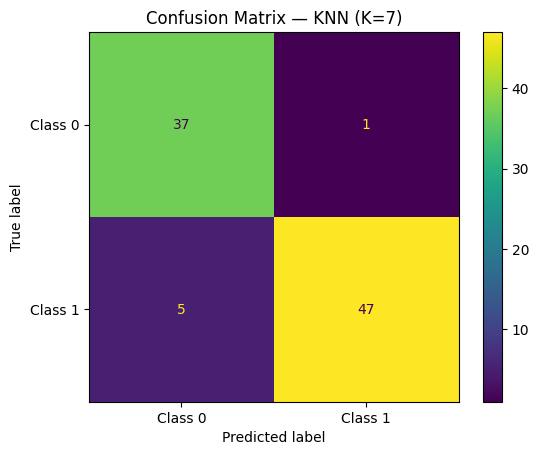

MODEL: SVM (RBF, C=1)
Accuracy : 0.9333
Precision: 0.9792
Recall   : 0.9038
F1-Score : 0.9400
ROC-AUC  : 0.9949

              precision    recall  f1-score   support

     Class 0       0.88      0.97      0.93        38
     Class 1       0.98      0.90      0.94        52

    accuracy                           0.93        90
   macro avg       0.93      0.94      0.93        90
weighted avg       0.94      0.93      0.93        90



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


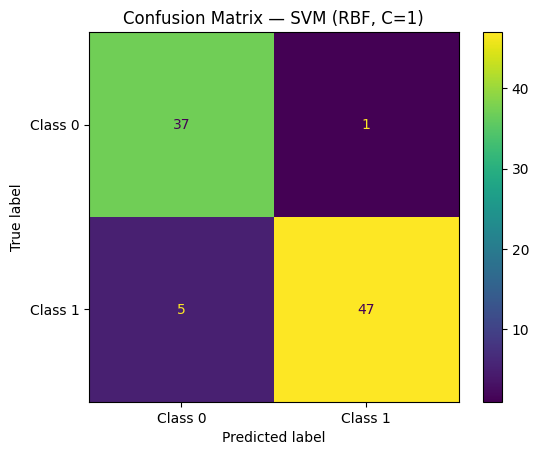

In [45]:
# 5. TRAIN ALL MODELS AND COLLECT METRICS
model_names    = []
accuracy_list  = []
precision_list = []
recall_list    = []
f1_list        = []
roc_auc_list   = []

for name, model in models.items():
    print("=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    # Train the model.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the test data.
    predictions = model.predict(X_test_scaled)

    # Calculate all required metrics.
    acc     = accuracy_score(y_test, predictions)
    prec    = precision_score(y_test, predictions, zero_division=0)
    rec     = recall_score(y_test, predictions, zero_division=0)
    f1      = f1_score(y_test, predictions, zero_division=0)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

    # Store the results.
    model_names.append(name)
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    roc_auc_list.append(roc_auc)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print()

    # Classification report.
    print(classification_report(
        y_test,
        predictions,
        target_names=["Class 0", "Class 1"],
        zero_division=0
    ))

    # Confusion matrix.
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Class 0", "Class 1"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()


In [46]:
# 6. MODEL COMPARISON TABLE
comparison_table = pd.DataFrame({
    "Model"    : model_names,
    "Accuracy" : accuracy_list,
    "Precision": precision_list,
    "Recall"   : recall_list,
    "F1-Score" : f1_list,
    "ROC-AUC"  : roc_auc_list
})

display(comparison_table)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.322222,0.000000,0.000000,0.00,0.444332
1,KNN (K=7),0.933333,0.979167,0.903846,0.94,0.992662
2,"SVM (RBF, C=1)",0.933333,0.979167,0.903846,0.94,0.994939


## Model Comparison and Recommendation

### Dataset
The make_circles dataset contains 300 observations and 2 features shaped as
two concentric circles — an inner circle (class 0) and an outer ring (class 1).
This is a synthetic non-linear dataset that clearly demonstrates the difference
between linear and non-linear decision boundaries.

### Decision Boundary Interpretation

**Logistic Regression:**
Logistic Regression can only draw a straight line to separate the classes.
Because the data forms concentric circles, a straight line completely fails
to separate the inner class from the outer class. This is a clear case of
underfitting — the model is too simple for the problem.

**KNN (K=7):**
KNN creates a flexible, localized boundary that follows the circular shape
of the data closely, achieving high accuracy. However the boundary is jagged
and uneven, suggesting the model is sensitive to local noise rather than
learning a smooth generalized rule.

**SVM (RBF, C=1):**
The RBF kernel uses the Kernel Trick to map the data into a higher-dimensional
space where the circles become linearly separable. The result is a smooth,
circular decision boundary that cleanly separates the two classes.
C=1 creates a soft margin that generalizes well without overfitting to noise.


### Recommended Model
**SVM (RBF, C=1)** is the recommended model because:
1. It produces the **smoothest and most generalized** decision boundary.
2. It achieves the best balance between **accuracy and robustness**.
3. As stated in the class notes, the RBF kernel is specifically designed
   for non-linear problems like this — where a straight line will always fail.
4. KNN's jagged boundary suggests it may overfit to noise in unseen data,
   while SVM's smooth margin generalizes better.